In [89]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

import aymansigmri as asm

## Goal: Test SVD Function and determine scaling issue

In [66]:
## Load ZTE style data and transform to hankel matrix

zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

data, n_coils, N_x, N_y = asm.hankel(kspace_cart_coils, w=5)
data_posthankel = asm.hankel_H_averaged(data_matrix = data, n_coils = kspace_cart_coils.shape[0], Nx = kspace_cart_coils.shape[1], Ny = kspace_cart_coils.shape[2], w=5)
data_posthankel = asm.hankel_H(data_matrix = data, n_coils = kspace_cart_coils.shape[0], Nx = kspace_cart_coils.shape[1], Ny = kspace_cart_coils.shape[2], w=5)

### Test for inconsistencies between pre and post hankel data matrix

In [67]:
## Testing on the hankel operators
np.allclose(kspace_cart_coils, data_posthankel, rtol=0, atol=0)

False

In [68]:
data_posthankel = asm.hankel_H(data_matrix = data, n_coils = kspace_cart_coils.shape[0], Nx = kspace_cart_coils.shape[1], Ny = kspace_cart_coils.shape[2], w=5)

np.allclose(kspace_cart_coils, data_posthankel, rtol=0, atol=0)

False

In [69]:
print(f"kspace_cart_coils shape: {kspace_cart_coils.shape}")
data, N_c, N_x, N_y = asm.hankel(kspace_cart_coils, w=5)


data_recon = asm.hankel_H(data, N_c, Nx=256, Ny=256, w=5)
print(f"Reconstructed shape: {data_recon.shape}")
print(f"Match: {np.allclose(kspace_cart_coils, data_recon)}")

kspace_cart_coils shape: (12, 256, 256)
Reconstructed shape: (12, 256, 256)
Match: True


In [70]:
error = np.abs(kspace_cart_coils - data_posthankel)
print(f"Max error: {error.max()}")
print(f"Mean error: {error.mean()}")
print(f"Relative error: {error.max() / np.abs(kspace_cart_coils).max()}")

Max error: 2.6492794179222862e-08
Mean error: 1.3784429115590633e-11
Relative error: 3.05006745574481e-08


In [72]:
### SVD Functions for building U, Sigma and Vh

def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def svd_recon(u, s_reduced, vh):
    return u @ np.diag(s_reduced) @ vh

### Test Consistency
1. `np.allclose`
2. Divide to find average errors

In [79]:
arr1 = np.arange(1, 109).reshape(3, 6, 6)

dataarray, N_c, N_x, N_y = asm.hankel(arr1, 5)

arr2 = asm.hankel_H_averaged(dataarray, N_c, Nx=6, Ny=6, w=5)
np.allclose(arr1, arr2)

U, S_reduced, Vh = sig_val_thresholding(data=dataarray, zero_thresh=0.0)
data_recon = svd_recon(u=U, s_reduced=S_reduced, vh=Vh)

In [77]:
np.allclose(dataarray, data_recon)

True

In [83]:
## Load ZTE style data and transform to hankel matrix

data, n_coils, N_x, N_y = asm.hankel(kspace_cart_coils, w=5)

In [ ]:
U, S_reduced, Vh = sig_val_thresholding(data=data, zero_thresh=0.0)
data_recon = svd_recon(u=U, s_reduced=S_reduced, vh=Vh)
kspace_recon = asm.hankel_H_averaged(data_matrix=data_recon, n_coils=12, Nx=256, Ny=256, w=5)
zte_recon = asm.nufft_degridding(cartesian_kspace=kspace_recon, coords=zte_radial_coords)

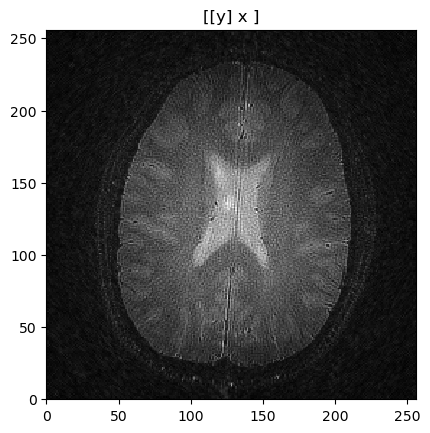

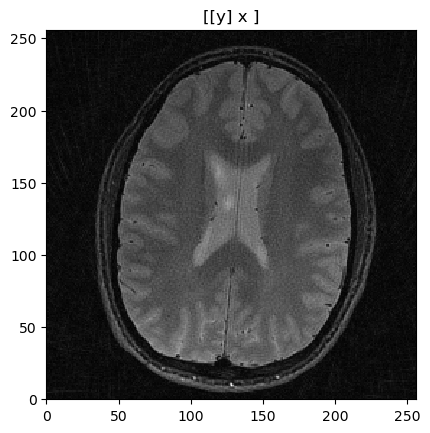

In [100]:
asm.im_recon_zte(zte_recon, zte_radial_coords)
asm.im_recon_zte(zte_radial_kspace, zte_radial_coords)